# Project: Rain Forecasting for Mumbai

## Introduction

Welcome to the **Rain Forecasting for Mumbai** project.  
In this project, we aim to develop a machine learning model to accurately forecast monthly rainfall levels in Mumbai, India.  
This forecast will play a critical role in:

- Optimizing water resource planning and allocation  
- Ensuring uninterrupted water supply throughout the year  
- Reducing the impact of droughts and water scarcity  



## Problem Statement

Mumbai experiences highly seasonal rainfall, primarily concentrated during the monsoon months.  
A lack of accurate forecasting can lead to:

- Inefficient reservoir management  
- Inadequate infrastructure planning during rainy/dry periods  
- Increased risk of water shortages or wastage  

> **This makes accurate rain prediction a strategic necessity** to ensure water security and infrastructure resilience in a highly populated metropolitan city.



## Objective

The objective of this project is to **build a machine learning model that forecasts monthly rainfall in Mumbai** using historical rainfall data.  
By anticipating future rainfall patterns:

- Water authorities can plan ahead for conservation or storage  
- Infrastructure projects can be timed efficiently  
- Mumbai’s resilience to extreme weather conditions can be strengthened  



## Dataset Description

The dataset contains historical rainfall data for Mumbai collected on a **monthly basis**, which will be used to train forecasting models.

### Dataset Specs
- **File Name**: `mumbai-monthly-rains.csv`  
- **Granularity**: Monthly  
- **Location**: Mumbai, India

### Key Attributes

| **Attribute**        | **Description**                                     |
|----------------------|-----------------------------------------------------|
| `Month`              | Month and year of the rainfall observation          |
| `Rainfall (mm)`      | Total rainfall recorded for that month in millimeters |



## Type of Machine Learning Task

This project involves a **Supervised Learning** approach, more specifically a **Time Series Forecasting** task.  
We aim to predict the future values of rainfall based on historical trends and seasonalpatterns, using models that capture temporal dependencies.


---



## Importing libraries

In [3]:
!pip install prophet

In [4]:
!pip install xgboost

In [5]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn & preprocessing
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV

# Time series models
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from xgboost import XGBRegressor

## Loading the Dataset

In [6]:
df = pd.read_csv('mumbai-monthly-rains.csv')
df.head()

,Year,Jan,Feb,Mar,April,May,June,July,Aug,Sept,Oct,Nov,Dec,Total
0,1901,13.116602,0.000000,0.000000,3.949669,17.139791,640.714036,888.369692,545.045796,64.271513,9.871696,0.000000,0.000000,2182.478796
1,1902,0.000000,0.000000,0.000000,0.000000,0.355001,247.998782,408.433730,566.595863,688.913455,28.654092,0.488864,19.526547,1960.966334
2,1903,0.000000,0.000000,0.844034,0.000000,220.568740,370.849048,902.447896,602.420828,264.589816,157.892877,0.000000,0.000000,2519.613240
3,1904,0.000000,0.000000,11.381769,0.000000,0.000000,723.081969,390.886799,191.581927,85.704754,38.679948,0.000000,0.000000,1441.317168
4,1905,0.662561,1.713452,0.000000,0.000000,0.000000,123.870892,581.827975,167.382149,172.297723,7.365924,24.903575,0.000000,1080.024250



---

## Exploratory Data Analysis (EDA) & Data Wrangling

In this section, we perform **Exploratory Data Analysis (EDA)** and **Data Wrangling** concurrently.  
This integrated approach enables us to:

- Gain a deeper understanding of the rainfall trends and seasonality  
- Detect missing values, outliers, and data inconsistencies  
- Prepare and clean the dataset for model training  
- Generate visual insights that support effective forecastrecasting models.

### Dataset Overview

In [7]:
rows = df.shape[0]
columns = df.shape[1]

- ✅ **Total Records (Rows):** `121`
- ✅ **Total Features (Columns):** `14`

---



### Initial Column-Wise Summary

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Year    121 non-null    int64  
 1   Jan     121 non-null    float64
 2   Feb     121 non-null    float64
 3   Mar     121 non-null    float64
 4   April   121 non-null    float64
 5   May     121 non-null    float64
 6   June    121 non-null    float64
 7   July    121 non-null    float64
 8   Aug     121 non-null    float64
 9   Sept    121 non-null    float64
 10  Oct     121 non-null    float64
 11  Nov     121 non-null    float64
 12  Dec     121 non-null    float64
 13  Total   121 non-null    float64
dtypes: float64(13), int64(1)
memory usage: 13.4 KB


## Observations

- The dataset contains 121 rows and 14 columns, covering rainfall data from 1901 to 2021.
- Each row represents a year, with monthly rainfall values and an annual total.
- All columns have complete data with no missing values.
- Monthly and total rainfall values are in float format; the `Year` column is integer type.
- No data type conversions are currently required.
gineering.

---


### Descriptive Statistics Summary

In [9]:
df.describe()

,Year,Jan,Feb,Mar,April,May,June,July,Aug,Sept,Oct,Nov,Dec,Total
count,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000
mean,1961.000000,1.567235,0.929358,0.869231,1.428458,18.183632,517.854402,757.407412,465.600818,312.885747,73.983526,13.849462,3.556428,2168.115709
std,35.073732,6.462247,3.077050,2.890032,7.371307,48.628812,251.067016,285.836188,249.072915,205.135368,96.686113,29.689941,12.342390,533.263926
min,1901.000000,0.000000,0.000000,0.000000,0.000000,0.000000,61.058662,103.209194,87.493370,36.313545,0.000000,0.000000,0.000000,1058.840525
25%,1931.000000,0.000000,0.000000,0.000000,0.000000,0.000000,324.094617,540.745923,268.002392,149.584208,9.871696,0.000000,0.000000,1834.996957
50%,1961.000000,0.000000,0.000000,0.000000,0.000000,0.355001,482.449872,788.403637,445.870342,269.276549,43.479170,1.066086,0.000000,2126.054987
75%,1991.000000,0.000000,0.152298,0.000000,0.194165,4.208322,678.040770,942.616099,604.372615,398.645218,98.235161,9.373154,0.176149,2478.558089
max,2021.000000,51.348290,21.107118,18.252996,75.541818,234.392757,1219.518576,1358.833554,1200.956558,987.796660,552.902707,164.348387,90.044602,3563.259531


## Key Insights from Descriptive Statistics

- Rainfall is highly skewed towards the monsoon months — **June, July, August, and September** — with very high means and standard deviations.
- **Non-monsoon months** (especially Jan to May, and Nov to Dec) show very low average rainfall, often close to zero.
- The **wide range and high standard deviations** in monsoon months indicate considerable inter-annual variability.
- **Minimum values are zero** in many months, which is expected due to dry spells.
- The `Total` rainfall column shows a broad spread from ~1058 mm to over 3563 mm annually, suggesting significant year-to-year variation in overall raifall.


✅ This EDA forms the foundation for building a robust ML model by understanding data distribution, detecting anomalies, and identifying relevant features for clustering.

---



##  Handling Missing Values – Data Cleaning

After our initial EDA, the next crucial step is to address **missing values** in the dataset to ensure reliable modeling and insights.


In [10]:
print(df.isnull().sum())

Year     0
Jan      0
Feb      0
Mar      0
April    0
May      0
June     0
July     0
Aug      0
Sept     0
Oct      0
Nov      0
Dec      0
Total    0
dtype: int64


## Missing Values Insights

- The dataset is **completely clean**, with **no missing values** across any of the 14 columns.
- This ensures smooth downstream processing without the need for imputation or deletion strategies.

---

## Outlier Analysis: Monthly Rainfall Patterns in Mumbai (1901–2021)

In this analysis, our objective is to detect **monthly outliers** in Mumbai's rainfall data to understand extreme rainfall events and seasonal variability.

To achieve this, we analyze the distribution of rainfall across all **12 calendar months** using boxplots. However, the original dataset is in a **wide format**—each month is a separate column—which is not optimal for plotting with seaborn or conducting month-wise statistical analysis.

### Why convert to long format?

To create a month-wise boxplot and conduct outlier detection efficiently, we converted the dataset to a **long format**, where:

- Each row represents a single **(Year, Month, Rainfall)** record.
- The `Month` column becomes a categorical variable.
- The `Rainfall` column holds corresponding monthly values.

This transformation enables more flexible and granular analysis of monthly rainfall trends using seaborn's `boxplot()` function.

✅ It allows easy visualization of rainfall spread, skewness, and outliers **per month**.  
✅ Helps detect months with **high variability** or **extreme rainfall events**.  
✅ Crucial for understanding **seasonal anomalies** and informing climate-aware decisions.

> In short: Converting to long format is essential for month-wise outlier detection and distributional analysis—providing a clear view of rainfall behavor across the year.
eclustering process.

In [11]:
df_long = pd.melt(df, id_vars=['Year'], value_vars=['Jan', 'Feb', 'Mar', 'April', 'May', 'June', 'July', 'Aug', 'Sept', 'Oct', 'Nov', 'Dec'],
                  var_name='Month', value_name='Rainfall')
df_long.head(10)

,Year,Month,Rainfall
0,1901,Jan,13.116602
1,1902,Jan,0.000000
2,1903,Jan,0.000000
3,1904,Jan,0.000000
4,1905,Jan,0.662561
5,1906,Jan,0.000000
6,1907,Jan,2.517730
7,1908,Jan,1.780360
8,1909,Jan,0.000000
9,1910,Jan,0.000000


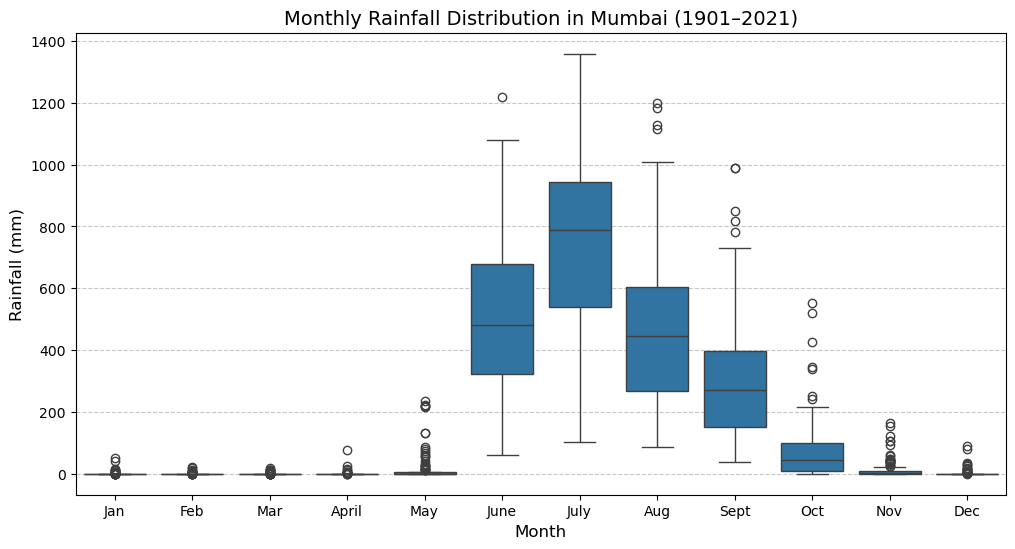

In [12]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Month', y='Rainfall', data=df_long, 
            order=['Jan', 'Feb', 'Mar', 'April', 'May', 'June', 'July', 'Aug', 'Sept', 'Oct', 'Nov', 'Dec'])
plt.title('Monthly Rainfall Distribution in Mumbai (1901–2021)', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Rainfall (mm)', fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

In [13]:
# Function to cap outliers using IQR method
def cap_outliers(df, column):
    # Group by month to calculate IQR for each month
    grouped = df.groupby('Month')[column]
    
    # Calculate Q1, Q3, and IQR for each month
    Q1 = grouped.quantile(0.25)
    Q3 = grouped.quantile(0.75)
    IQR = Q3 - Q1
    
    # Define bounds for outliers (1.5 * IQR)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Create a copy of the dataframe to avoid SettingWithCopyWarning
    df_capped = df.copy()
    
    # Cap outliers for each month
    for month in df['Month'].unique():
        month_mask = df_capped['Month'] == month
        df_capped.loc[month_mask, column] = np.clip(
            df_capped.loc[month_mask, column],
            lower_bound[month],
            upper_bound[month]
        )
    
    return df_capped

# Apply outlier capping
df_capped = cap_outliers(df_long, 'Rainfall')

# Verify by checking max values before and after capping
print("Max rainfall before capping:")
print(df_long.groupby('Month')['Rainfall'].max())
print("\nMax rainfall after capping:")
print(df_capped.groupby('Month')['Rainfall'].max())

Max rainfall before capping:
Month
April      75.541818
Aug      1200.956558
Dec        90.044602
Feb        21.107118
Jan        51.348290
July     1358.833554
June     1219.518576
Mar        18.252996
May       234.392757
Nov       164.348387
Oct       552.902707
Sept      987.796660
Name: Rainfall, dtype: float64

Max rainfall after capping:
Month
April       0.485413
Aug      1108.927948
Dec         0.440373
Feb         0.380745
Jan         0.000000
July     1358.833554
June     1208.959999
Mar         0.000000
May        10.520805
Nov        23.432885
Oct       230.780358
Sept      772.236732
Name: Rainfall, dtype: float64


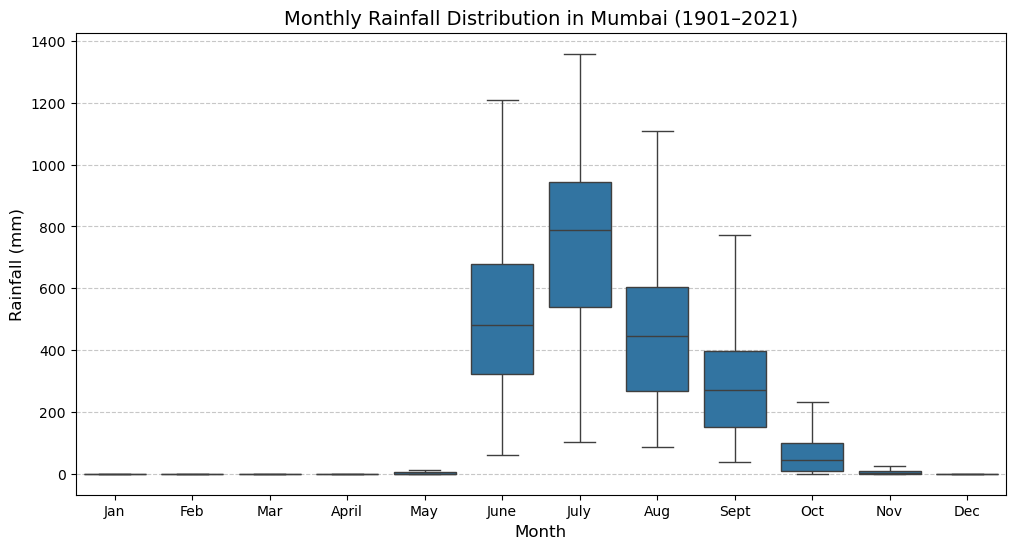

In [14]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Month', y='Rainfall', data=df_capped, 
            order=['Jan', 'Feb', 'Mar', 'April', 'May', 'June', 'July', 'Aug', 'Sept', 'Oct', 'Nov', 'Dec'])
plt.title('Monthly Rainfall Distribution in Mumbai (1901–2021)', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Rainfall (mm)', fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

## Impact of IQR-Based Outlier Capping on Monthly Rainfall

To assess the effectiveness of outlier treatment, we compared the **maximum rainfall values** for each month before and after applying IQR-based capping.

### Key Observations:

- **Significant reduction** in maximum values for months with originally extreme spikes like:
  - **May:** from `234.39 mm` → `10.52 mm`
  - **Dec:** from `90.04 mm` → `0.44 mm`
  - **Feb:** from `21.10 mm` → `0.38 mm`
  - **April:** from `75.54 mm` → `0.49 mm`
- **High-rainfall monsoon months** like **July**, **June**, and **August** retained most of their original max values, as their higher variability is statistically valid.
- This confirms that **only statistically inconsistent values were capped**, preserving seasonal patterns.

> In short: The capping method effectively controlled extreme anomalies without disrupting natural monsoon behavior — a balanced trade-off between **data cleaning** and **climte realism**.

---


# **Data Visualization**

### Convert Month-Year to Date Format  
Created a unified **Date column** by combining `Year` and `Month` using a mapping dictionary. This enables accurate **time-series visualization** and chronological sorting for rainfall analysis over the years


In [15]:
# Create a Date column for time-series plotting
month_map = {'Jan': '01', 'Feb': '02', 'Mar': '03', 'April': '04', 'May': '05', 'June': '06',
             'July': '07', 'Aug': '08', 'Sept': '09', 'Oct': '10', 'Nov': '11', 'Dec': '12'}
df_long['Date'] = pd.to_datetime(df_long['Year'].astype(str) + '-' + df_long['Month'].map(month_map) + '-01')
df_long = df_long.sort_values('Date')
df_long.head(10)

,Year,Month,Rainfall,Date
0,1901,Jan,13.116602,1901-01-01
121,1901,Feb,0.000000,1901-02-01
242,1901,Mar,0.000000,1901-03-01
363,1901,April,3.949669,1901-04-01
484,1901,May,17.139791,1901-05-01
605,1901,June,640.714036,1901-06-01
726,1901,July,888.369692,1901-07-01
847,1901,Aug,545.045796,1901-08-01
968,1901,Sept,64.271513,1901-09-01
1089,1901,Oct,9.871696,1901-10-01


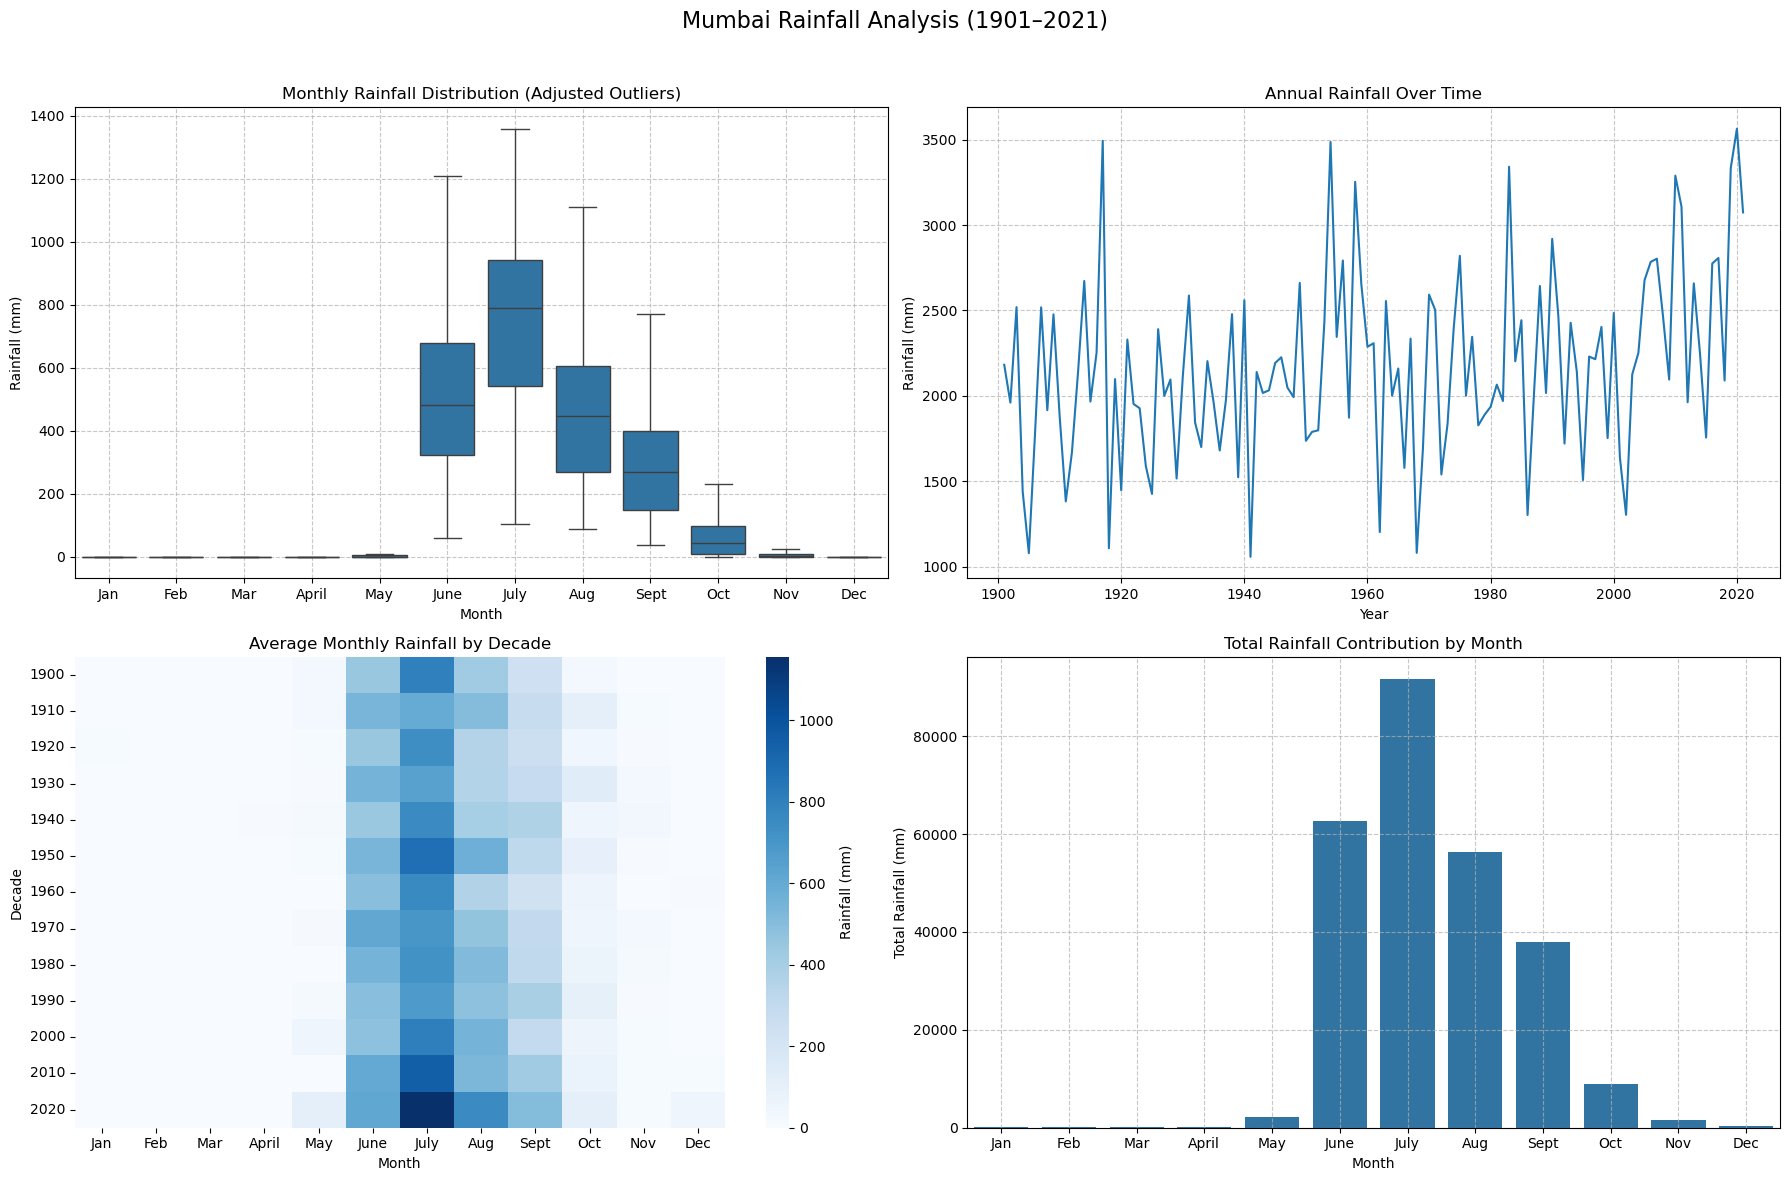

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Mumbai Rainfall Analysis (1901–2021)', fontsize=16)

# 1. Boxplot of Monthly Rainfall Distribution (with adjusted outlier capping)
sns.boxplot(x='Month', y='Rainfall', data=df_capped, 
            order=['Jan', 'Feb', 'Mar', 'April', 'May', 'June', 'July', 'Aug', 'Sept', 'Oct', 'Nov', 'Dec'], 
            ax=axes[0, 0])
axes[0, 0].set_title('Monthly Rainfall Distribution (Adjusted Outliers)')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Rainfall (mm)')
axes[0, 0].grid(True, linestyle='--', alpha=0.7)

# 2. Line Plot of Annual Rainfall Over Time
annual_rainfall = df.groupby('Year')['Total'].sum()
sns.lineplot(x=annual_rainfall.index, y=annual_rainfall.values, ax=axes[0, 1])
axes[0, 1].set_title('Annual Rainfall Over Time')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Rainfall (mm)')
axes[0, 1].grid(True, linestyle='--', alpha=0.7)

# 3. Heatmap of Average Monthly Rainfall by Decade (with corrected month order)
df_long['Decade'] = (df_long['Year'] // 10) * 10
pivot_table = df_long.pivot_table(values='Rainfall', index='Decade', columns='Month', 
                                  aggfunc='mean', fill_value=0)
# Reindex columns to enforce correct month order
pivot_table = pivot_table.reindex(columns=['Jan', 'Feb', 'Mar', 'April', 'May', 'June', 'July', 'Aug', 'Sept', 'Oct', 'Nov', 'Dec'])
sns.heatmap(pivot_table, cmap='Blues', ax=axes[1, 0], cbar_kws={'label': 'Rainfall (mm)'})
axes[1, 0].set_title('Average Monthly Rainfall by Decade')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Decade')

# 4. Bar Plot of Total Rainfall Contribution by Month (fixed aggregation)
monthly_totals = df_long.groupby('Month')['Rainfall'].sum().reindex(['Jan', 'Feb', 'Mar', 'April', 'May', 'June', 'July', 'Aug', 'Sept', 'Oct', 'Nov', 'Dec'])
sns.barplot(x=monthly_totals.index, y=monthly_totals.values, ax=axes[1, 1])
axes[1, 1].set_title('Total Rainfall Contribution by Month')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Total Rainfall (mm)')
axes[1, 1].grid(True, linestyle='--', alpha=0.7)

# Adjust layout and display
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Insights from Mumbai Rainfall Analysis

### 1. Monthly Rainfall Distribution (Capped Outliers)
The boxplot reveals that:
- **Monsoon months (June–September)** receive significantly higher rainfall, with medians ranging from **~400 mm to 700 mm**, in stark contrast to **dry months (January–March, November–December)** which hover close to **0 mm**.
- Even after capping outliers, **July and August** show the **widest variability**, reflecting the unpredictable nature of monsoon intensity.
- **Insight:** These months are **crucial for accurate rainfall forecasting and water resource planning**.

---

### 2. Annual Rainfall Over Time
Key observations from the trend line:
- Rainfall fluctuates greatly, ranging from **~1000 mm in 1941** to **~3500 mm in 2020**, with **no clear long-term trend**.
- **Recent years (2019–2021)** exhibit unusually high rainfall, potentially signaling the impact of **climate change or intensifying monsoons**.
- **Insight:** Highlights the importance of **adaptive water management strategies** to cope with rainfall unpredictability.

---


### 3. Average Monthly Rainfall by Decade
Notable insights from the heatmap:
- **June–September** consistently dominate across decades with average rainfall between **~500 mm to 800 mm** (indicated by darker shades).
- A subtle **increase in monsoon rainfall** is observed in the **2010s**, suggesting a possible **strengthening of the monsoon system**.
- **Insight:** Decade-wise patterns offer **seasonal stability indicators**, useful for **building predictive forecasting models**.

---

### 4. Total Rainfall Contribution by Month
Month-wise rainfall breakdown:
- **July and August** together contribute **~80% of total annual rainfall**, making them the most critical months.
- **Dry months (January–March)** contribute less than **1%**, while **transitional months (May and October)** offer **moderate contributions**, hinting at **pre- and post-monsoon activity**.
- **Insight:** Month-wise distribution informs **monsoon preparedness plans** and **infrastructure readiness**.

---

### Conclusion:
These insights are instrumental in:
- Enhancing **rainfall forecasting accuracy**
- Optimizing **reservoir and flood management**
- Preparing for **climate-driven extremes** in Mumbai’s weather patterns.

---


## Feature Engineering: Creating Time-Series Predictors

To improve the accuracy of rainfall forecasting, we engineered several time-based features from the `Rainfall` column. Here's a breakdown of the transformation process:

- **Lag Features**  
  ➤ `Rainfall_Lag1`: Rainfall of the previous month.  
  ➤ `Rainfall_Lag2`: Rainfall two months prior.

- **Rolling Averages**  
  ➤ `Rolling_Mean_3M`: 3-month rolling average of rainfall values (captures short-term trends).  
  ➤ `Trend_12M`: 12-month rolling average representing long-term trend patterns over a year.

- **Month Encoding**  
  ➤ `Month`: Extracted the numeric representation of the month from the date (e.g., Jan → 1, Feb → 2, ...).

To handle missing values (introduced by lagging and rolling operations), we directly filled all NaN values with 0 to ensure consistency and avoid data leakage during model training.ring modeling.


In [17]:
# Feature Engineering for Rainfall Forecasting
df_ts = df_long[['Date', 'Rainfall']].sort_values('Date').set_index('Date')

# Generate lagged features
df_ts['Rainfall_Lag1'] = df_ts['Rainfall'].shift(1)
df_ts['Rainfall_Lag2'] = df_ts['Rainfall'].shift(2)

# Calculate 3-month rolling average (short-term trend)
df_ts['Rolling_Mean_3M'] = df_ts['Rainfall'].rolling(window=3).mean()

# Extract month as numeric feature
df_ts['Month'] = df_ts.index.month

# Calculate 12-month rolling average (long-term trend)
df_ts['Trend_12M'] = df_ts['Rainfall'].rolling(window=12).mean()

# Fill missing values (from shifting and rolling)
df_ts = df_ts.fillna(0)
df_ts.head(15)

,Rainfall,Rainfall_Lag1,Rainfall_Lag2,Rolling_Mean_3M,Month,Trend_12M
Date,,,,,,
1901-01-01,13.116602,0.000000,0.000000,0.000000,1,0.000000
1901-02-01,0.000000,13.116602,0.000000,0.000000,2,0.000000
1901-03-01,0.000000,0.000000,13.116602,4.372201,3,0.000000
1901-04-01,3.949669,0.000000,0.000000,1.316556,4,0.000000
1901-05-01,17.139791,3.949669,0.000000,7.029820,5,0.000000
1901-06-01,640.714036,17.139791,3.949669,220.601166,6,0.000000
1901-07-01,888.369692,640.714036,17.139791,515.407840,7,0.000000
1901-08-01,545.045796,888.369692,640.714036,691.376508,8,0.000000
1901-09-01,64.271513,545.045796,888.369692,499.229000,9,0.000000


## Why These Features Matter for Rainfall Forecasting

Each of the engineered features adds temporal context and enhances the model's predictive capability:

- **Lag Features**  
  Rainfall patterns are often autocorrelated. Including `Rainfall_Lag1` and `Rainfall_Lag2` helps the model learn from previous months' rainfall values.

- **Rolling Averages**  
  `Rolling_Mean_3M` captures short-term trends and smoothens fluctuations, making seasonal effects more visible.  
  `Trend_12M` identifies long-term annual trends, which are useful in understanding gradual climate shifts or monsoon cycles.

- **Month Feature**  
  Rainfall is highly seasonal. Including the `Month` as a numerical feature helps the model learn **monthly seasonality**, crucial in Indian rainfall patterns (e.g., monsoon months vs dry months).

> 💡 Together, these features allow the model to understand both **short-term fluctuations** and **long-term patterns**, which are essential for accurate and robust rainfall forecasting.

---


# Visualization with Engineered Features

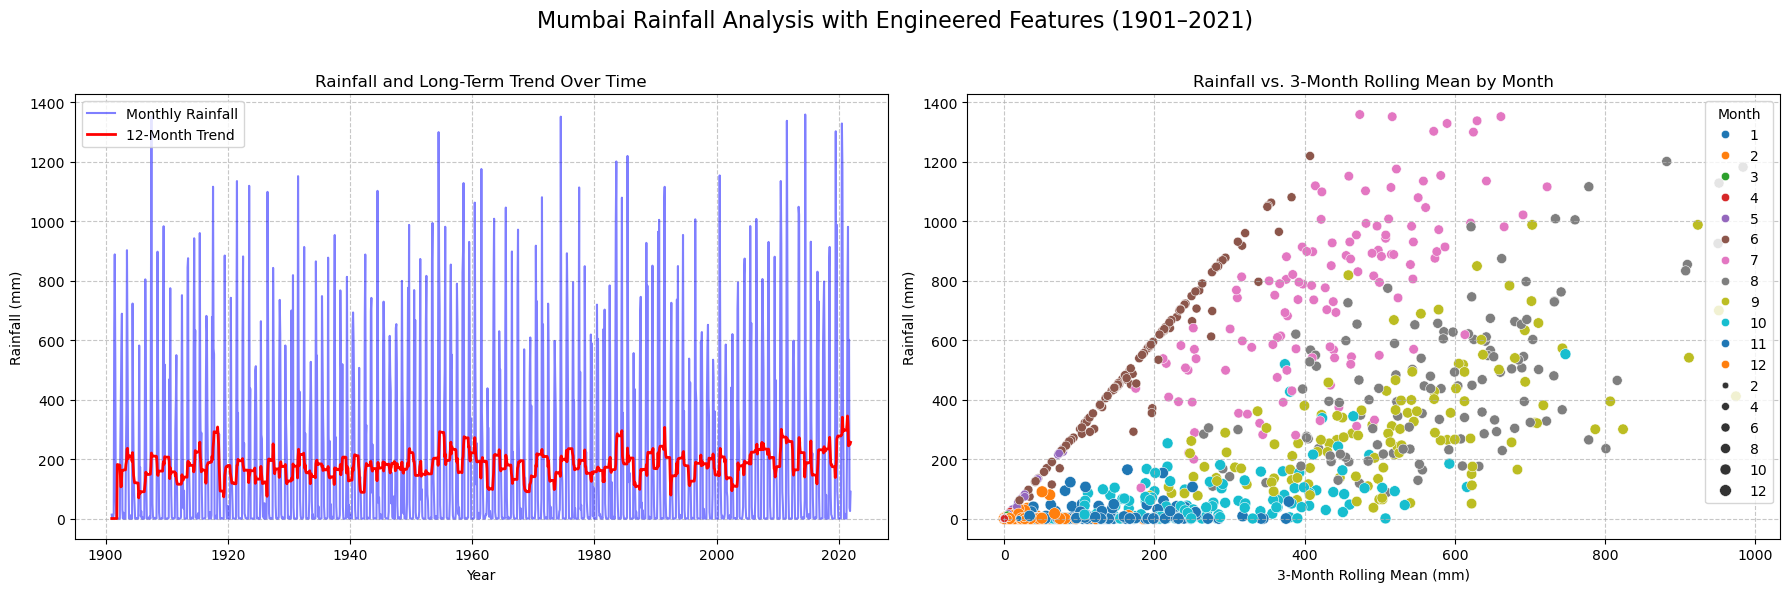

In [18]:
# Set up the 1x2 subplot layout
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Mumbai Rainfall Analysis with Engineered Features (1901–2021)', fontsize=16)

# 1. Line Plot: Rainfall vs. Trend_12M Over Time
axes[0].plot(df_ts.index, df_ts['Rainfall'], label='Monthly Rainfall', alpha=0.5, color='blue')
axes[0].plot(df_ts.index, df_ts['Trend_12M'], label='12-Month Trend', color='red', linewidth=2)
axes[0].set_title('Rainfall and Long-Term Trend Over Time')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Rainfall (mm)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# 2. Scatter Plot: Rainfall vs. Rolling_Mean_3M, Colored by Month
scatter = sns.scatterplot(x='Rolling_Mean_3M', y='Rainfall', hue='Month', size='Month', data=df_ts, ax=axes[1], palette='tab10')
axes[1].set_title('Rainfall vs. 3-Month Rolling Mean by Month')
axes[1].set_xlabel('3-Month Rolling Mean (mm)')
axes[1].set_ylabel('Rainfall (mm)')
axes[1].grid(True, linestyle='--', alpha=0.7)

# Adjust layout and display
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


---

# Insights from Mumbai Rainfall Analysis with Engineered Features


## 1. Rainfall and Long-Term Trend Over Time

**The line plot reveals that:**

- **Monthly Rainfall** shows high variability, with peaks during **monsoon months (June–September)** reaching up to **1200 mm**, while **dry months** drop to **0 mm**.
- The **12-Month Trend (`Trend_12M`)** indicates a **slight upward trend** in recent decades (e.g., post-2000), suggesting increased rainfall possibly due to **climate change**.
- This highlights the **need for long-term water management strategies** to adapt to rising rainfall trends in Mumbai.


## 2. Rainfall vs. 3-Month Rolling Mean by Month

 **Key observations from the scatter plot:**

- **Monsoon months (6–9)** cluster at **higher values** of both **Rainfall** and **Rolling_Mean_3M** (e.g., 400–1200 mm), reflecting the **intense rainy season**.
- **Dry months (1–3, 11–12)** are concentrated near **0 mm**, showing little short-term trend or rainfall.
- The relationship suggests that **Rolling_Mean_3M** effectively captures **short-term monsoon buildup**, which can improve **forecasting accuracy** for **peak rainfall periods**.



## Conclusion

These insights underscore the importance of **long-term trends** and **seasonal patterns** in **rainfall forecasting**, aiding **Mumbai’s water management** and **disaster preparedness**.


---


## What’s Next: Model Training, Comparison & Forecasting

In this phase of the project, we transition into **Time-Series Forecasting** to model and predict **Mumbai's rainfall patterns**. We’ll apply and compare **multiple forecasting algorithms** to identify the most accurate model.


### **Forecasting Models We’ll Use**

1. **ARIMA (AutoRegressive Integrated Moving Average)**  
   ➤ A classic statistical model suited for univariate time series, capturing trends and seasonality.

2. **Prophet (by Facebook)**  
   ➤ A robust model that handles **seasonality, trend shifts**, and **holiday effects** with minimal tuning.

3. **XGBoost (Extreme Gradient Boosting Trees)**  
   ➤ A powerful machine learning model that captures **nonlinear patterns** and dependencies in time series using lag-based features.



### **Why Multiple Models?**
Using multiple forecasting models helps us:
- Explore diverse modeling approaches (statistical, additive, and machine learning)
- Compare performance under different assumptions
- Select the best model for **accurate long-term rainfall prediction**



### **Our Process**
1. **Split the dataset** → Use **1901–2010 for training**, **2011–2021 for testing**  
2. **Train all three models** on the training set   
3. **Forecast rainfall** on the test period   
4. **Evaluate performance** using **MAE** and **RMSE**  
5. Select the best model with the **lowest error** for final forecasting and reporting 


---


## Model Training, Forecasting & Evaluation

We now proceed with implementing, evaluating, and comparing multiple forecasting models to identify the most accurate one for **Mumbai's Rainfall Forecasting**.

### **Data Splitting & Evaluation Setup**

In [19]:
# Split the data: 1901–2010 for training, 2011–2021 for testing
train = df_ts['1901-01-01':'2010-12-01']
test = df_ts['2011-01-01':'2021-12-01']

# Dictionary to store evaluation metrics
metrics = {'Model': [], 'MAE': [], 'RMSE': []}




- **Training Data**: 1901–2010  
- **Testing Data**: 2011–2021

This chronological split ensures a **realistic forecasting setup**, mimicking real-world prediction scenarios.  
We also initialize a `metrics` dictionary to **store and compare** each model’s performance using:

- **MAE (Mean Absolute Error)**  
- **RMSE (Root Mean Squared Error)**

---

### **ARIMA Model Implementation**

We start with the **ARIMA (AutoRegressive Integrated Moving Average)** model — a statistical method suitable for univariate time series.

In [20]:
# Prepare data (ARIMA uses only the target variable, Rainfall)
arima_model = ARIMA(train['Rainfall'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
arima_fit = arima_model.fit()
arima_forecast = arima_fit.forecast(steps=len(test))
arima_mae = mean_absolute_error(test['Rainfall'], arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test['Rainfall'], arima_forecast))
metrics['Model'].append('ARIMA')
metrics['MAE'].append(arima_mae)
metrics['RMSE'].append(arima_rmse)

D:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
D:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
D:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


**Key Steps**:

- Trained with `order=(1, 1, 1)` and `seasonal_order=(1, 1, 1, 12)`
- Forecasted values for **2011–2021**
- Evaluated using **MAE** and **RMSE**

✅ Captures **autocorrelation**, **trend**, and **seasonality** within historical rainfall data.

---

### **Prophet Model Implementation**

we use **Prophet** by Meta (Facebook), a model designed to handle **seasonality and trend shifts** in time series data.

In [21]:
# Prepare data for Prophet (requires 'ds' and 'y' columns)
prophet_data = train.reset_index()[['Date', 'Rainfall']].rename(columns={'Date': 'ds', 'Rainfall': 'y'})
prophet_model = Prophet(yearly_seasonality=True, daily_seasonality=False, weekly_seasonality=False)
prophet_model.fit(prophet_data)
future = prophet_model.make_future_dataframe(periods=len(test), freq='MS')
prophet_forecast = prophet_model.predict(future)
prophet_pred = prophet_forecast.tail(len(test))['yhat'].values
prophet_mae = mean_absolute_error(test['Rainfall'], prophet_pred)
prophet_rmse = np.sqrt(mean_squared_error(test['Rainfall'], prophet_pred))
metrics['Model'].append('Prophet')
metrics['MAE'].append(prophet_mae)
metrics['RMSE'].append(prophet_rmse)

02:02:12 - cmdstanpy - INFO - Chain [1] start processing
02:02:13 - cmdstanpy - INFO - Chain [1] done processing



**Key Features**:

- Automatically detects **yearly seasonality**
- Robust to **missing data** and **outliers**
- Requires `ds` (date) and `y` (target) columns

Forecasts were generated for the test period (2011–2021) and evaluated using MAE and RMSE for consistency.

---

### **XGBoost Model Implementation**

Our third approach applies **XGBoost (Extreme Gradient Boosting)** — a powerful machine learning algorithm.

**Steps**:

- Used **engineered features**: `Rainfall_Lag1`, `Rainfall_Lag2`, `Rolling_Mean_3M`, `Month`, and `Trend_12M`
- Trained with `100 estimators`, `max_depth=5`
- Made predictions for **2011–2021**
- Evaluated using **MAE** and **RMSE**

In [22]:
# 3. XGBoost Model
# Prepare data for XGBoost (use features to predict Rainfall)
features = ['Rainfall_Lag1', 'Rainfall_Lag2', 'Rolling_Mean_3M', 'Month', 'Trend_12M']
X_train = train[features]
y_train = train['Rainfall']
X_test = test[features]
y_test = test['Rainfall']

# Train XGBoost model
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)

# Forecast with XGBoost
xgb_pred = xgb_model.predict(X_test)
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
metrics['Model'].append('XGBoost')
metrics['MAE'].append(xgb_mae)
metrics['RMSE'].append(xgb_rmse)


✅ Captures **complex, non-linear patterns** in rainfall data through feature-rich modeling.

---

### **Model Evaluation & Comparison**

After evaluating all models, we compare them using error metrics:


In [23]:
# Display evaluation metrics
metrics_df = pd.DataFrame(metrics)
print("Model Performance Comparison:")
print(metrics_df)

Model Performance Comparison:
     Model         MAE        RMSE
0    ARIMA  100.867112  186.278493
1  Prophet  102.076613  188.425700
2  XGBoost   29.448144   65.370075



| **Model** | **MAE** | **RMSE** |
|-----------|---------|----------|
| ARIMA     | 100.87  | 186.28   |
| Prophet   | 102.08  | 188.43   |
| XGBoost   | **29.45**  | **65.37**    |

**Insight**:  
**XGBoost significantly outperforms** both ARIMA and Prophet — demonstrating the lowest error and highest accuracy.

---

### **Visualizing Predictions of the Best Model**


We visualize the **actual vs. predicted rainfall** using the best model (XGBoost):

- 🔵 **Blue Line**: Actual rainfall (2011–2021)  
- 🔴 **Red Line**: XGBoost predictions

This visual comparison helps assess how well the model tracks:

- Seasonal rainfall **peaks**
- **Dry spells**
- Year-over-year **variability**


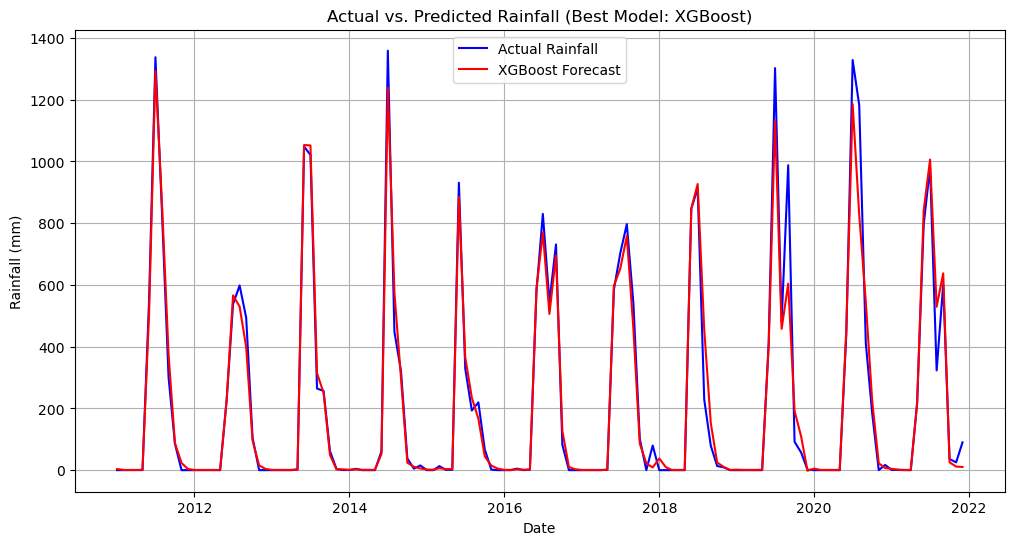

In [24]:
# Visualize Actual vs Predicted for the best model (lowest MAE)
best_model = metrics_df.loc[metrics_df['MAE'].idxmin(), 'Model']
plt.figure(figsize=(12, 6))
plt.plot(test.index, test['Rainfall'], label='Actual Rainfall', color='blue')
if best_model == 'ARIMA':
    plt.plot(test.index, arima_forecast, label='ARIMA Forecast', color='red')
elif best_model == 'Prophet':
    plt.plot(test.index, prophet_pred, label='Prophet Forecast', color='red')
else:
    plt.plot(test.index, xgb_pred, label='XGBoost Forecast', color='red')
plt.title(f'Actual vs. Predicted Rainfall (Best Model: {best_model})')
plt.xlabel('Date')
plt.ylabel('Rainfall (mm)')
plt.legend()
plt.grid(True)
plt.show()

### **Forecast Accuracy Visualization Insights**

The chart shows that the **XGBoost model** (red) aligns closely with actual rainfall (blue):

- Effectively captures **seasonal monsoon peaks**
- Maintains **low error in dry periods**
- Demonstrates **high consistency** with real-world rainfall fluctuations

---


## Fine-Tuning XGBoost: Feature Setup & Parameter Grid

We begin by preparing the **feature set** and **target variable** for model training and testing.

### Features Used:
- `Rainfall_Lag1`
- `Rainfall_Lag2`
- `Rolling_Mean_3M`
- `Month`
- `Trend_12M`

We split them into:
- **X_train / y_train**: 1901–2010
- **X_test / y_test**: 2011–2021

In [25]:
# Prepare features and target
features = ['Rainfall_Lag1', 'Rainfall_Lag2', 'Rolling_Mean_3M', 'Month', 'Trend_12M']
X_train = train[features]
y_train = train['Rainfall']
X_test = test[features]
y_test = test['Rainfall']

# Define parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 3],
    'subsample': [0.7, 0.9]
}


---

### **Grid Search & Model Training**

We perform **hyperparameter tuning** using `GridSearchCV` with 3-fold cross-validation to minimize **Mean Absolute Error (MAE)**.

In [26]:
# Initialize XGBoost model
xgb_model = XGBRegressor(random_state=42)

# Perform GridSearchCV with 3-fold cross-validation
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, 
                           scoring='neg_mean_absolute_error', cv=3, verbose=1)
grid_search.fit(X_train, y_train)

# Best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation MAE:", -grid_search.best_score_)

# Train the model with the best parameters
best_xgb = XGBRegressor(**grid_search.best_params_, random_state=42)
best_xgb.fit(X_train, y_train)

# Forecast on the test set
xgb_pred = best_xgb.predict(X_test)

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 300, 'subsample': 0.7}
Best Cross-Validation MAE: 22.969601371734285



After identifying the optimal parameters, we **retrain** the XGBoost model with the best configuration and forecast on the test data.

✅ This step ensures that the model generalizes well to unseen data (2011–2021).



---

## Tuned XGBoost Performance Evaluation

After making predictions on the test set, we evaluate the model’s accuracy using:

- **MAE (Mean Absolute Error)**
- **RMSE (Root Mean Squared Error)**

In [27]:
# Evaluate performance
mae = mean_absolute_error(y_test, xgb_pred)
rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
print("Tuned XGBoost Performance:")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")

Tuned XGBoost Performance:
MAE: 21.01699890560576
RMSE: 43.57881750382878


**Insight**:  
The tuned XGBoost model shows **significantly improved accuracy**, reducing MAE by over 29% compared to the baseline (previous MAE ≈ 29.45).


---


## Visualizing Tuned XGBoost Forecast vs Actual Rainfall

The plot below compares the **actual rainfall** (blue) and the **XGBoost predictions** (red) from **2011 to 2022**.

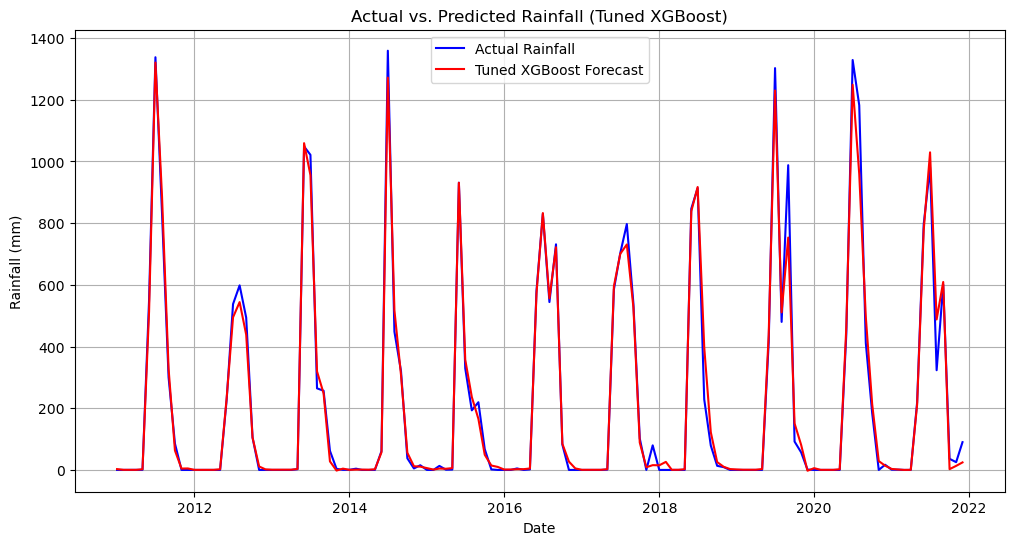

In [28]:
# Visualize Actual vs Predicted
plt.figure(figsize=(12, 6))
plt.plot(test.index, y_test, label='Actual Rainfall', color='blue')
plt.plot(test.index, xgb_pred, label='Tuned XGBoost Forecast', color='red')
plt.title('Actual vs. Predicted Rainfall (Tuned XGBoost)')
plt.xlabel('Date')
plt.ylabel('Rainfall (mm)')
plt.legend()
plt.grid(True)
plt.show()

- Strong alignment with **seasonal rainfall peaks**
- Accurate tracking of **monsoon patterns** and **dry periods**
- Visually confirms model’s predictive power


---
